# Task 1A

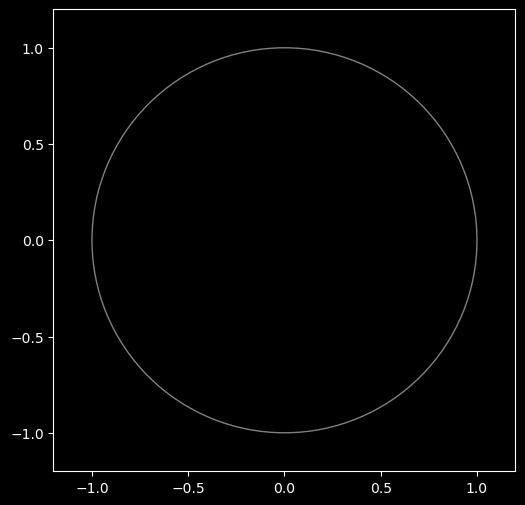

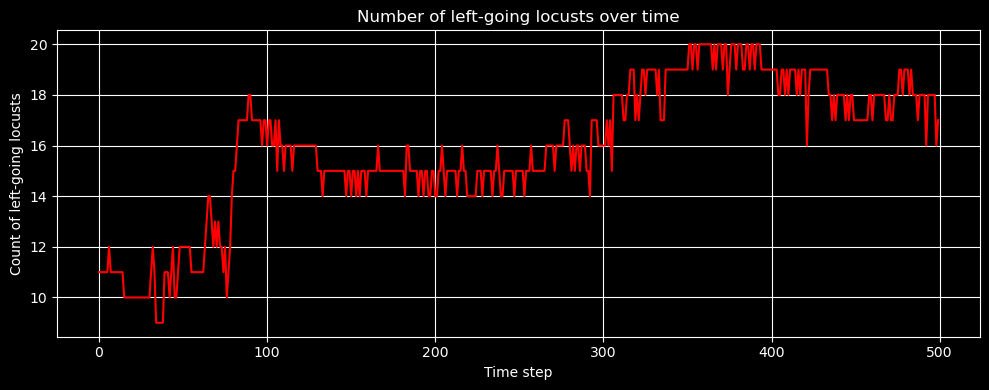

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
N = 20
C = 1.0
v_abs = 0.001
r = 0.045
P = 0.015
timesteps = 500

# Initialization
positions = np.random.rand(N)
velocities = np.random.choice([-v_abs, v_abs], size=N)

# Store data for animation and plotting
positions_over_time = []
velocities_over_time = []
left_counts = []

for t in range(timesteps):
    new_velocities = velocities.copy()

    for i in range(N):
        # Compute ring distances
        distances = np.abs(positions - positions[i])
        distances = np.minimum(distances, C - distances)

        # Find neighbors
        in_range = (distances <= r) & (np.arange(N) != i)
        left = np.sum(velocities[in_range] < 0)
        right = np.sum(velocities[in_range] > 0)

        # Majority rule
        if velocities[i] < 0 and right > left:
            new_velocities[i] = v_abs
        elif velocities[i] > 0 and left > right:
            new_velocities[i] = -v_abs

        # Spontaneous switch
        if np.random.rand() < P:
            new_velocities[i] *= -1

    velocities = new_velocities
    positions = (positions + velocities) % C

    # Store data
    positions_over_time.append(positions.copy())
    velocities_over_time.append(velocities.copy())
    left_counts.append(np.sum(velocities < 0))

# --- Animation ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
circle = plt.Circle((0, 0), 1.0, color='gray', fill=False)
ax.add_artist(circle)
scat = ax.scatter([], [], s=80)

def init():
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    return scat,

def update(frame):
    pos = positions_over_time[frame]
    vel = velocities_over_time[frame]
    angles = 2 * np.pi * pos
    x = np.cos(angles)
    y = np.sin(angles)
    colors = ['red' if v < 0 else 'blue' for v in vel]
    scat.set_offsets(np.c_[x, y])
    scat.set_color(colors)
    ax.set_title(f'Time: {frame} | Left-going: {np.sum(vel < 0)}')
    return scat,

ani = animation.FuncAnimation(fig, update, frames=timesteps,
                              init_func=init, blit=True, interval=30, repeat=False)

# Show animation
plt.show()

# --- Plot at the end ---
plt.figure(figsize=(10, 4))
plt.plot(left_counts, color='red')
plt.title('Number of left-going locusts over time')
plt.xlabel('Time step')
plt.ylabel('Count of left-going locusts')
plt.grid(True)
plt.tight_layout()
plt.show()


# Task 1B

Running simulations: 100%|██████████| 1000/1000 [01:55<00:00,  8.69it/s]


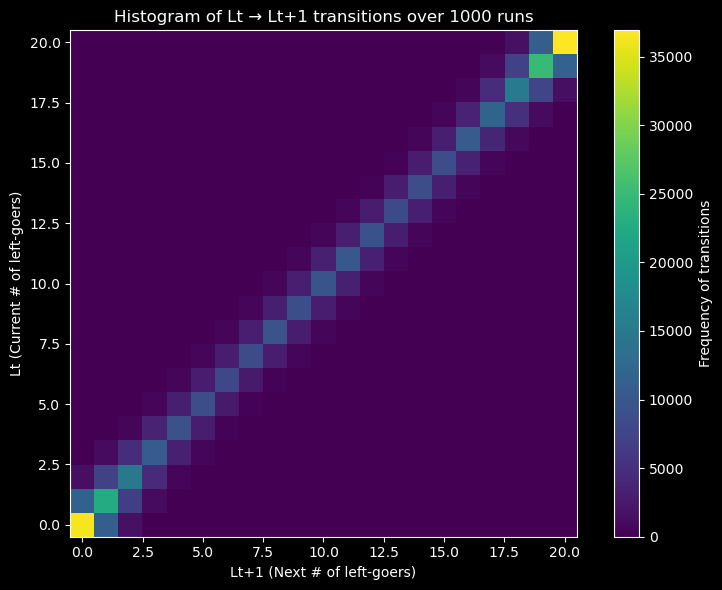

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # For progress bar

# Parameters
N = 20
C = 1.0
v_abs = 0.001
r = 0.045
P = 0.015
timesteps = 500
runs = 1000

# Initialize 2D histogram A[Lt][Lt+1]
A = np.zeros((N + 1, N + 1), dtype=int)

# Simulation loop
for run in tqdm(range(runs), desc="Running simulations"):
    positions = np.random.rand(N)
    velocities = np.random.choice([-v_abs, v_abs], size=N)

    left_count = np.sum(velocities < 0)

    for t in range(timesteps):
        new_velocities = velocities.copy()
        for i in range(N):
            # Compute ring distances
            distances = np.abs(positions - positions[i])
            distances = np.minimum(distances, C - distances)
            in_range = (distances <= r) & (np.arange(N) != i)
            left = np.sum(velocities[in_range] < 0)
            right = np.sum(velocities[in_range] > 0)

            # Majority switch
            if velocities[i] < 0 and right > left:
                new_velocities[i] = v_abs
            elif velocities[i] > 0 and left > right:
                new_velocities[i] = -v_abs

            # Spontaneous switch
            if np.random.rand() < P:
                new_velocities[i] *= -1

        velocities = new_velocities
        positions = (positions + velocities) % C

        # Next left count
        new_left_count = np.sum(velocities < 0)

        # Record transition
        A[left_count][new_left_count] += 1
        left_count = new_left_count

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(A, origin='lower', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Frequency of transitions')
plt.xlabel('Lt+1 (Next # of left-goers)')
plt.ylabel('Lt (Current # of left-goers)')
plt.title('Histogram of Lt → Lt+1 transitions over 1000 runs')
plt.tight_layout()
plt.show()


# Task 1C

Running simulations: 100%|██████████| 100/100 [00:11<00:00,  8.48it/s]


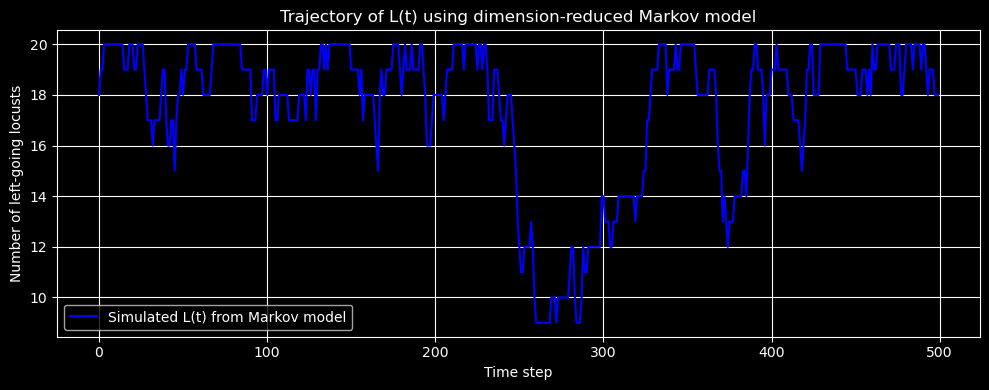

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# Parameters
N = 20
C = 1.0
v_abs = 0.001
r = 0.045
P = 0.015
timesteps = 500
runs = 100

# Initialize matrices
A = np.zeros((N + 1, N + 1), dtype=int)  # transition counts
M = np.zeros(N + 1, dtype=int)          # occurrence counts

# Run simulations
for run in tqdm(range(runs), desc="Running simulations"):
    positions = np.random.rand(N)
    velocities = np.random.choice([-v_abs, v_abs], size=N)
    left_count = np.sum(velocities < 0)

    for t in range(timesteps):
        new_velocities = velocities.copy()
        for i in range(N):
            distances = np.abs(positions - positions[i])
            distances = np.minimum(distances, C - distances)
            in_range = (distances <= r) & (np.arange(N) != i)
            left = np.sum(velocities[in_range] < 0)
            right = np.sum(velocities[in_range] > 0)

            if velocities[i] < 0 and right > left:
                new_velocities[i] = v_abs
            elif velocities[i] > 0 and left > right:
                new_velocities[i] = -v_abs

            if np.random.rand() < P:
                new_velocities[i] *= -1

        velocities = new_velocities
        positions = (positions + velocities) % C

        new_left_count = np.sum(velocities < 0)

        # Record transition and state count
        A[left_count][new_left_count] += 1
        M[left_count] += 1

        left_count = new_left_count

# Compute transition probabilities P[i][j] = A[i][j] / M[i]

transition_matrix = np.zeros_like(A, dtype=float)

# Replace further references:
for i in range(N + 1):
    if M[i] > 0:
        transition_matrix[i, :] = A[i, :] / M[i]

# --- Simulate Markov chain using transition_matrix ---
L_trajectory = []
L = np.random.randint(0, N + 1)  # initial state

for t in range(timesteps):
    L_trajectory.append(L)
    probs = transition_matrix[L]
    if probs.sum() == 0:  # no transition data; stay in place
        break
    L = np.random.choice(np.arange(N + 1), p=probs)
    

output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

# --- Plot L_trajectory (dimension-reduced model) ---
plt.figure(figsize=(10, 4))
plt.plot(L_trajectory, label='Simulated L(t) from Markov model', color='blue')
plt.xlabel('Time step')
plt.ylabel('Number of left-going locusts')
plt.title('Trajectory of L(t) using dimension-reduced Markov model')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Task 1Compare

Building transition matrix: 100%|██████████| 1000/1000 [01:54<00:00,  8.77it/s]


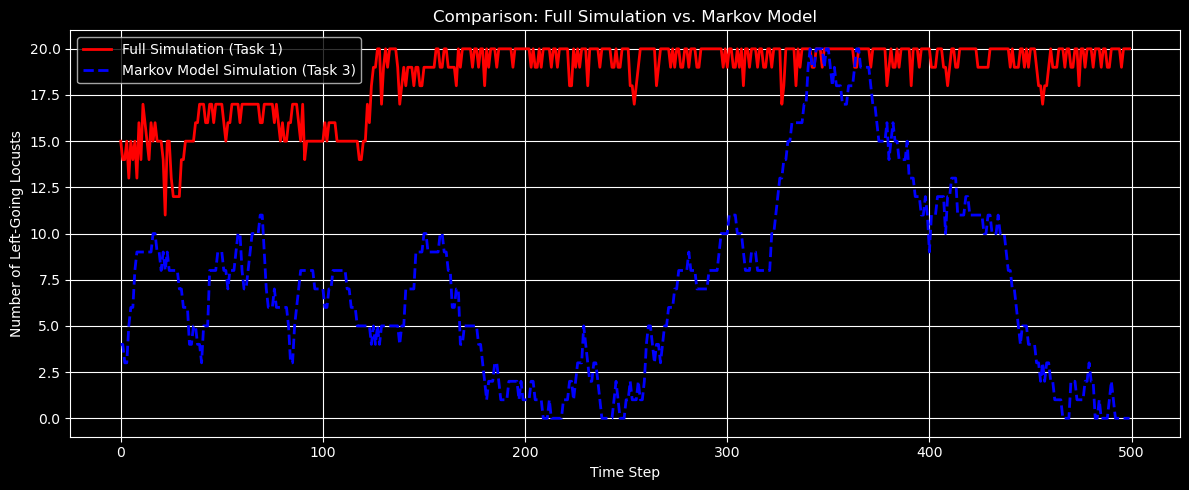

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
# --- PARAMETERS ---
N = 20
C = 1.0
v_abs = 0.001
r = 0.045
P_switch = 0.015
timesteps = 500
runs = 1000  # for better estimation of P matrix

# --- TASK 1: Full Simulation ---
positions = np.random.rand(N)
velocities = np.random.choice([-v_abs, v_abs], size=N)

left_counts = []

for t in range(timesteps):
    new_velocities = velocities.copy()

    for i in range(N):
        distances = np.abs(positions - positions[i])
        distances = np.minimum(distances, C - distances)
        in_range = (distances <= r) & (np.arange(N) != i)
        left = np.sum(velocities[in_range] < 0)
        right = np.sum(velocities[in_range] > 0)

        if velocities[i] < 0 and right > left:
            new_velocities[i] = v_abs
        elif velocities[i] > 0 and left > right:
            new_velocities[i] = -v_abs

        if np.random.rand() < P_switch:
            new_velocities[i] *= -1

    velocities = new_velocities
    positions = (positions + velocities) % C
    left_counts.append(np.sum(velocities < 0))

# --- TASK 3: Build P matrix using many runs ---
A = np.zeros((N + 1, N + 1), dtype=int)
M = np.zeros(N + 1, dtype=int)

for run in tqdm(range(runs), desc="Building transition matrix"):
    positions = np.random.rand(N)
    velocities = np.random.choice([-v_abs, v_abs], size=N)
    left_count = np.sum(velocities < 0)

    for t in range(timesteps):
        new_velocities = velocities.copy()
        for i in range(N):
            distances = np.abs(positions - positions[i])
            distances = np.minimum(distances, C - distances)
            in_range = (distances <= r) & (np.arange(N) != i)
            left = np.sum(velocities[in_range] < 0)
            right = np.sum(velocities[in_range] > 0)

            if velocities[i] < 0 and right > left:
                new_velocities[i] = v_abs
            elif velocities[i] > 0 and left > right:
                new_velocities[i] = -v_abs

            if np.random.rand() < P_switch:
                new_velocities[i] *= -1

        velocities = new_velocities
        positions = (positions + velocities) % C

        new_left_count = np.sum(velocities < 0)

        A[left_count][new_left_count] += 1
        M[left_count] += 1

        left_count = new_left_count

# Normalize to get transition probabilities
P = np.zeros_like(A, dtype=float)
for i in range(N + 1):
    if M[i] > 0:
        P[i] = A[i] / M[i]

# --- Simulate Markov model using P ---
L_trajectory = []
L = np.random.randint(0, N + 1)

for t in range(timesteps):
    L_trajectory.append(L)
    probs = P[L]
    if probs.sum() == 0:
        break
    L = np.random.choice(np.arange(N + 1), p=probs)

output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: Task 1 (Full Simulation)
axs[0].plot(left_counts, color='red')
axs[0].set_title('Task 1: Full Locust Simulation')
axs[0].set_ylabel('Left-Going Locusts')
axs[0].grid(True)

# Bottom: Task 3 (Markov Model)
axs[1].plot(L_trajectory, color='blue', linestyle='--')
axs[1].set_title('Task 3: Markov Model Simulation')
axs[1].set_xlabel('Time Step')
axs[1].set_ylabel('Left-Going Locusts')
axs[1].grid(True)

# plt.tight_layout()
# plt.show()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'task1_task3_individual_plots.png'))
plt.close()

# --- COMPARISON PLOT ---
plt.figure(figsize=(12, 5))
plt.plot(left_counts, label='Full Simulation (Task 1)', color='red', linewidth=2)
plt.plot(L_trajectory, label='Markov Model Simulation (Task 3)', color='blue', linestyle='--', linewidth=2)
plt.xlabel('Time Step')
plt.ylabel('Number of Left-Going Locusts')
plt.title('Comparison: Full Simulation vs. Markov Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'task1_task3_comparison.png'))
plt.show()


# Task 2A

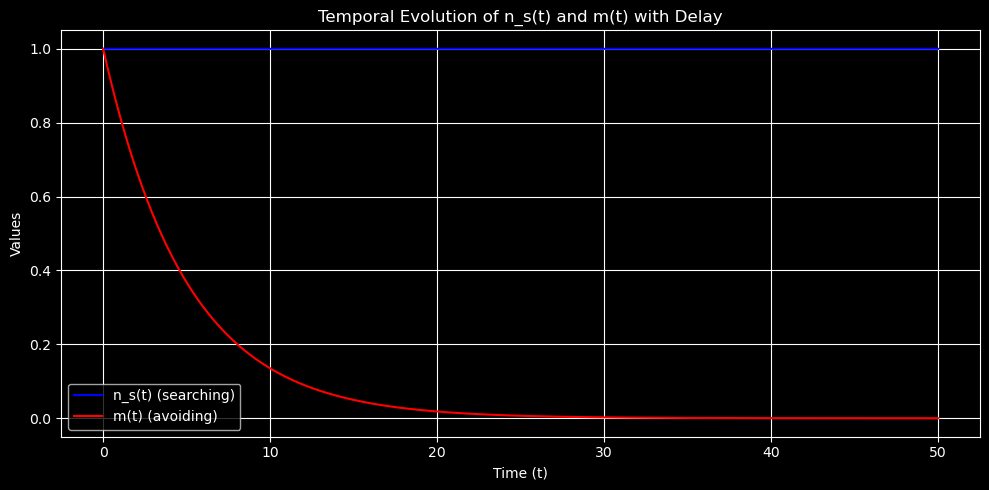

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
alpha_r = 0.6
alpha_p = 0.2
tau_a = 2.0
t_max = 50.0
dt = 0.01
n_steps = int(t_max / dt)

# Time array
t = np.linspace(0, t_max, n_steps)
ns = np.zeros(n_steps)
m = np.zeros(n_steps)

# Initial conditions
ns[0] = 1.0
m[0] = 1.0

# Delay steps
delay_steps = int(tau_a / dt)

for i in range(1, n_steps):
    # Current and delayed ns values
    ns_current = ns[i - 1]
    if i - delay_steps >= 0:
        ns_delayed = ns[i - delay_steps]
    else:
        ns_delayed = ns[0]  # Use initial value before delay time

    # Derivatives
    d_ns = -alpha_r * ns_current * (ns_current + 1) + alpha_r * ns_delayed * (ns_delayed + 1)
    d_m = -alpha_p * ns_current * m[i - 1]

    # Euler integration
    ns[i] = ns[i - 1] + dt * d_ns
    m[i] = m[i - 1] + dt * d_m

# --- Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(t, ns, label='n_s(t) (searching)', color='blue')
plt.plot(t, m, label='m(t) (avoiding)', color='red')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.title('Temporal Evolution of n_s(t) and m(t) with Delay')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

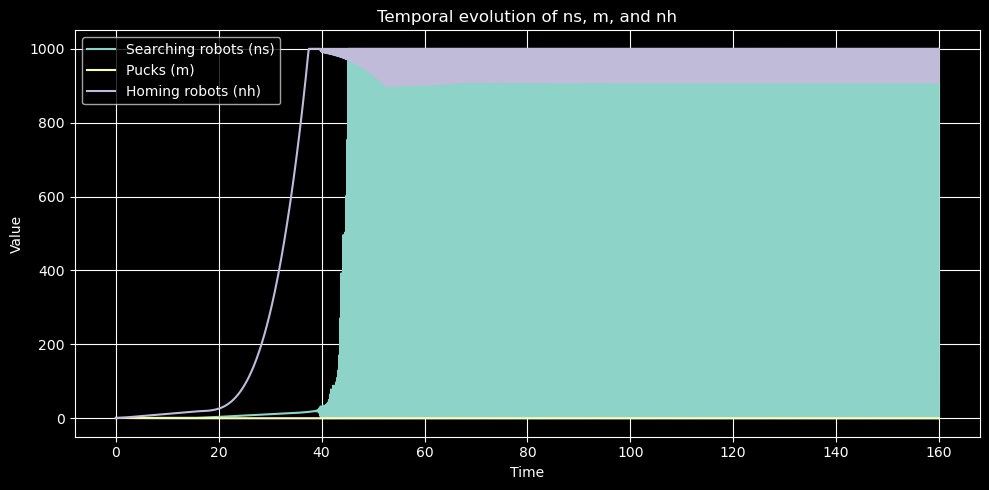

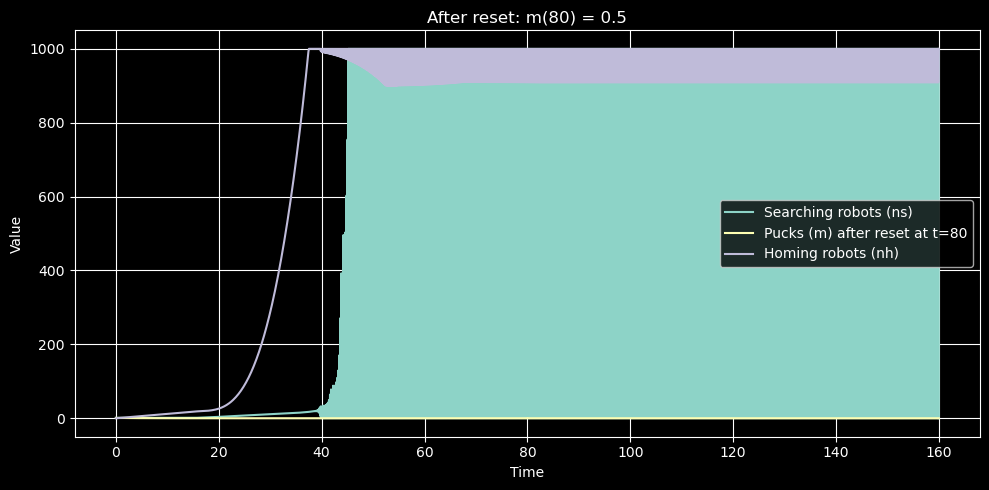

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
alpha_r = 0.6
alpha_p = 0.2
tau_a = 2
tau_h = 15

# Initial values
ns0 = 1.0
m0 = 1.0
nh0 = 0.0

# Simulation settings
t_max = 160
dt = 0.1
n_steps = int(t_max / dt)
time = np.linspace(0, t_max, n_steps)

# Delay steps
delay_a = int(tau_a / dt)
delay_h = int(tau_h / dt)

# Initialize arrays
ns = np.full(n_steps, ns0)
m = np.full(n_steps, m0)
nh = np.full(n_steps, nh0)

# Cap values to avoid overflow
CAP = 1e3

# Simulation loop
for i in range(1, n_steps):
    ns_curr = ns[i - 1]
    m_curr = m[i - 1]
    nh_curr = nh[i - 1]

    # Handle delays
    if i >= delay_a:
        ns_a = ns[i - delay_a]
    else:
        ns_a = ns0

    if i >= delay_h:
        nh_h = nh[i - delay_h]
    else:
        nh_h = 0.0

    # Rate equations
    d_ns = -alpha_r * ns_curr * (ns_curr + 1) + alpha_r * ns_a * (ns_a + 1) + nh_h
    d_m = -alpha_p * ns_curr * m_curr
    d_nh = alpha_r * ns_curr * (ns_curr + 1) - nh_h

    # Euler integration with clipping
    ns[i] = np.clip(ns[i - 1] + dt * d_ns, 0, CAP)
    m[i] = np.clip(m[i - 1] + dt * d_m, 0, CAP)
    nh[i] = np.clip(nh[i - 1] + dt * d_nh, 0, CAP)

# ---- Plot original result ----
plt.figure(figsize=(10, 5))
plt.plot(time, ns, label='Searching robots (ns)')
plt.plot(time, m, label='Pucks (m)')
plt.plot(time, nh, label='Homing robots (nh)')
plt.title("Temporal evolution of ns, m, and nh")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Reset m(80) = 0.5 and rerun ----
m_reset = m.copy()
ns2 = ns.copy()
nh2 = nh.copy()

for i in range(int(80 / dt), n_steps):
    ns_curr = ns2[i - 1]
    m_curr = m_reset[i - 1]
    nh_curr = nh2[i - 1]

    if i >= delay_a:
        ns_a = ns2[i - delay_a]
    else:
        ns_a = ns0

    if i >= delay_h:
        nh_h = nh2[i - delay_h]
    else:
        nh_h = 0.0

    d_ns = -alpha_r * ns_curr * (ns_curr + 1) + alpha_r * ns_a * (ns_a + 1) + nh_h
    d_m = -alpha_p * ns_curr * m_curr
    d_nh = alpha_r * ns_curr * (ns_curr + 1) - nh_h

    ns2[i] = np.clip(ns2[i - 1] + dt * d_ns, 0, CAP)
    m_reset[i] = np.clip(m_reset[i - 1] + dt * d_m, 0, CAP)
    nh2[i] = np.clip(nh2[i - 1] + dt * d_nh, 0, CAP)

    # Reset m(80) = 0.5
    if i == int(80 / dt):
        m_reset[i] = 0.5

# ---- Plot after m(80)=0.5 reset ----
plt.figure(figsize=(10, 5))
plt.plot(time, ns2, label='Searching robots (ns)')
plt.plot(time, m_reset, label='Pucks (m) after reset at t=80')
plt.plot(time, nh2, label='Homing robots (nh)')
plt.title("After reset: m(80) = 0.5")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()